In [2]:
print("Hello Hari! My first AI project has started 🚀")


Hello Hari! My first AI project has started 🚀


In [3]:
import pandas as pd

data = {
    "Study_Hours": [2, 3, 5, 1, 6, 4, 7, 2, 8, 5],
    "Attendance": [60, 65, 85, 50, 90, 75, 95, 55, 98, 80],
    "Assignments": [4, 5, 8, 3, 9, 7, 10, 4, 10, 8],
    "Previous_Marks": [45, 50, 70, 35, 80, 65, 85, 40, 90, 72],
    "Final_Marks": [48, 52, 75, 38, 85, 68, 90, 45, 94, 78]
}

df = pd.DataFrame(data)

df

,Study_Hours,Attendance,Assignments,Previous_Marks,Final_Marks
0,2,60,4,45,48
1,3,65,5,50,52
2,5,85,8,70,75
3,1,50,3,35,38
4,6,90,9,80,85
5,4,75,7,65,68
6,7,95,10,85,90
7,2,55,4,40,45
8,8,98,10,90,94
9,5,80,8,72,78


In [4]:
X = df[["Study_Hours", "Attendance", "Assignments", "Previous_Marks"]]
y = df["Final_Marks"]

print("Input Features:")
print(X)

print("\nTarget:")
print(y)

Input Features:
   Study_Hours  Attendance  Assignments  Previous_Marks
0            2          60            4              45
1            3          65            5              50
2            5          85            8              70
3            1          50            3              35
4            6          90            9              80
5            4          75            7              65
6            7          95           10              85
7            2          55            4              40
8            8          98           10              90
9            5          80            8              72

Target:
0    48
1    52
2    75
3    38
4    85
5    68
6    90
7    45
8    94
9    78
Name: Final_Marks, dtype: int64


In [5]:
X = df[["Study_Hours", "Attendance", "Assignments", "Previous_Marks"]]
y = df["Final_Marks"]

print("Input Features:")
print(X)

print("\nTarget:")
print(y)

Input Features:
   Study_Hours  Attendance  Assignments  Previous_Marks
0            2          60            4              45
1            3          65            5              50
2            5          85            8              70
3            1          50            3              35
4            6          90            9              80
5            4          75            7              65
6            7          95           10              85
7            2          55            4              40
8            8          98           10              90
9            5          80            8              72

Target:
0    48
1    52
2    75
3    38
4    85
5    68
6    90
7    45
8    94
9    78
Name: Final_Marks, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("AI model training completed successfully! 🤖")

AI model training completed successfully! 🤖


In [8]:
new_student = [[6, 88, 8, 75]]

prediction = model.predict(new_student)

print("Predicted Final Marks:", round(prediction[0], 2))

Predicted Final Marks: 79.45


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error: 1.96
R² Score: 0.99


In [11]:
study_hours = 6
attendance = 88
assignments = 8
previous_marks = 75

student_data = [[study_hours, attendance, assignments, previous_marks]]

prediction = model.predict(student_data)

print("Predicted Final Marks:", round(prediction[0], 2))

Predicted Final Marks: 79.45


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


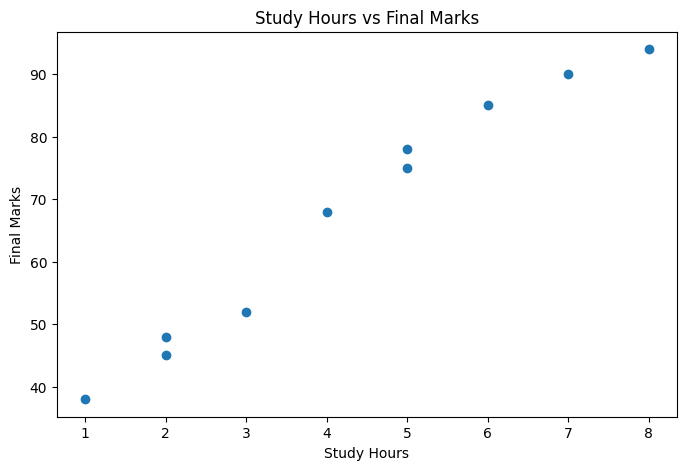

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours"], df["Final_Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.show()

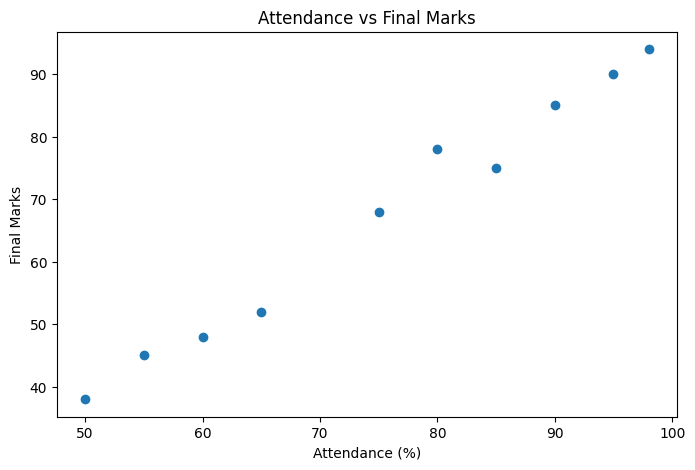

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Attendance"], df["Final_Marks"])

plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")

plt.show()

In [14]:
correlation = df.corr(numeric_only=True)

print(correlation["Final_Marks"].sort_values(ascending=False))

Final_Marks       1.000000
Previous_Marks    0.998458
Assignments       0.997070
Attendance        0.992285
Study_Hours       0.986889
Name: Final_Marks, dtype: float64


In [16]:
comparison = pd.DataFrame({
    "Actual_Marks": y_test.values,
    "Predicted_Marks": y_pred
})

comparison["Difference"] = (
    comparison["Actual_Marks"] - comparison["Predicted_Marks"]
).round(2)

comparison

,Actual_Marks,Predicted_Marks,Difference
0,94,95.824719,-1.82
1,52,54.095506,-2.10


In [18]:
!pip install -q gradio

In [19]:
import gradio as gr

def predict_marks(study_hours, attendance, assignments, previous_marks):
    student_data = [[study_hours, attendance, assignments, previous_marks]]
    prediction = model.predict(student_data)[0]

    return round(prediction, 2)


app = gr.Interface(
    fn=predict_marks,
    inputs=[
        gr.Number(label="Study Hours"),
        gr.Number(label="Attendance (%)"),
        gr.Number(label="Completed Assignments"),
        gr.Number(label="Previous Marks")
    ],
    outputs=gr.Number(label="Predicted Final Marks"),
    title="AI Student Performance Predictor",
    description="Enter student details to predict final marks using Machine Learning."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d7be7952fecfdb608b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# AI Student Performance Predictor

## Project Overview

This project uses Machine Learning to predict a student's final marks based on:

- Study Hours
- Attendance
- Completed Assignments
- Previous Marks

## Machine Learning Model

Linear Regression

## Technologies Used

Python
Pandas
Scikit-learn
Matplotlib
Gradio
Google Colab

## Project Workflow

Student Data
↓
Data Preparation
↓
Train/Test Split
↓
Machine Learning Model
↓
Prediction
↓
Model Evaluation
↓
Interactive Web Interface

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [20]:
import pandas as pd
import numpy as np

np.random.seed(42)

students = 200

data = {
    "Study_Hours": np.random.randint(1, 10, students),
    "Attendance": np.random.randint(50, 101, students),
    "Assignments": np.random.randint(3, 11, students),
    "Previous_Marks": np.random.randint(35, 96, students)
}

df = pd.DataFrame(data)

df["Final_Marks"] = (
    0.30 * df["Study_Hours"] * 10
    + 0.25 * df["Attendance"]
    + 1.5 * df["Assignments"]
    + 0.35 * df["Previous_Marks"]
    + np.random.normal(0, 5, students)
)

df["Final_Marks"] = df["Final_Marks"].clip(0, 100).round(2)

df.head()

,Study_Hours,Attendance,Assignments,Previous_Marks,Final_Marks
0,7,50,4,62,68.20
1,4,60,9,48,55.06
2,8,77,4,65,73.70
3,5,74,7,86,74.03
4,7,99,4,53,77.16


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Study_Hours", "Attendance", "Assignments", "Previous_Marks"]]
y = df["Final_Marks"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("New model trained successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

New model trained successfully!
Training samples: 160
Testing samples: 40


In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

Model Evaluation
-----------------
Mean Absolute Error: 5.0
R² Score: 0.68


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Evaluation")
print("------------------------")
print("Mean Absolute Error:", round(rf_mae, 2))
print("R² Score:", round(rf_r2, 2))

Random Forest Evaluation
------------------------
Mean Absolute Error: 5.74
R² Score: 0.53


In [24]:
new_student = [[7, 92, 9, 82]]

prediction = model.predict(new_student)

print("New Student Prediction")
print("----------------------")
print("Study Hours: 7")
print("Attendance: 92%")
print("Assignments: 9")
print("Previous Marks: 82")
print("Predicted Final Marks:", round(prediction[0], 2))

New Student Prediction
----------------------
Study Hours: 7
Attendance: 92%
Assignments: 9
Previous Marks: 82
Predicted Final Marks: 86.31


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
print("FINAL MODEL PERFORMANCE")
print("------------------------")
print("Linear Regression")
print("MAE:", round(mae, 2))
print("R² Score:", round(r2, 2))

print("\nRandom Forest")
print("MAE:", round(rf_mae, 2))
print("R² Score:", round(rf_r2, 2))

FINAL MODEL PERFORMANCE
------------------------
Linear Regression
MAE: 5.0
R² Score: 0.68

Random Forest
MAE: 5.74
R² Score: 0.53


In [26]:
new_student = [[7, 92, 9, 82]]

prediction = model.predict(new_student)

print("NEW STUDENT PREDICTION")
print("----------------------")
print("Study Hours: 7")
print("Attendance: 92%")
print("Assignments: 9")
print("Previous Marks: 82")
print("Predicted Final Marks:", round(prediction[0], 2))

NEW STUDENT PREDICTION
----------------------
Study Hours: 7
Attendance: 92%
Assignments: 9
Previous Marks: 82
Predicted Final Marks: 86.31


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [27]:
new_student = pd.DataFrame({
    "Study_Hours": [7],
    "Attendance": [92],
    "Assignments": [9],
    "Previous_Marks": [82]
})

prediction = model.predict(new_student)

print("NEW STUDENT PREDICTION")
print("----------------------")
print("Study Hours:", new_student["Study_Hours"].iloc[0])
print("Attendance:", new_student["Attendance"].iloc[0], "%")
print("Assignments:", new_student["Assignments"].iloc[0])
print("Previous Marks:", new_student["Previous_Marks"].iloc[0])
print("Predicted Final Marks:", round(prediction[0], 2))

NEW STUDENT PREDICTION
----------------------
Study Hours: 7
Attendance: 92 %
Assignments: 9
Previous Marks: 82
Predicted Final Marks: 86.31


In [28]:
import gradio as gr

def predict_marks(study_hours, attendance, assignments, previous_marks):

    student_data = pd.DataFrame({
        "Study_Hours": [study_hours],
        "Attendance": [attendance],
        "Assignments": [assignments],
        "Previous_Marks": [previous_marks]
    })

    prediction = model.predict(student_data)[0]

    return round(prediction, 2)


app = gr.Interface(
    fn=predict_marks,

    inputs=[
        gr.Number(
            label="Study Hours",
            minimum=0,
            maximum=24
        ),

        gr.Number(
            label="Attendance (%)",
            minimum=0,
            maximum=100
        ),

        gr.Number(
            label="Completed Assignments",
            minimum=0,
            maximum=10
        ),

        gr.Number(
            label="Previous Marks",
            minimum=0,
            maximum=100
        )
    ],

    outputs=gr.Number(
        label="Predicted Final Marks"
    ),

    title="🎓 AI Student Performance Predictor",

    description=(
        "Enter student academic details to predict "
        "their final marks using Machine Learning."
    )
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://450865d3b6eb9f2486.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
